## **EXTRA METRICS**

EXTRA METRICS EVALUATION
Loaded: arabicaqa_rag_results\predictions\comparison_llama_mistral_command_1000.csv
Shape: (1000, 21)
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command
 - llama
 - mistral

Boolean check:
is_impossible:
is_impossible
False    500
True     500
Name: count, dtype: int64

is_answerable:
is_answerable
True     500
False    500
Name: count, dtype: int64

Retrieved doc ids check:
[1732461, 1732461, 1727247, 1364429, 1583150]
[1450526, 1583712, 1363076, 1732200, 1732200]
[1451158, 1451255, 1338855, 1363187, 1727301]
[1364225, 1450308, 1450843, 1450306, 1363239]
[1451158, 1339069, 1451255, 1363090

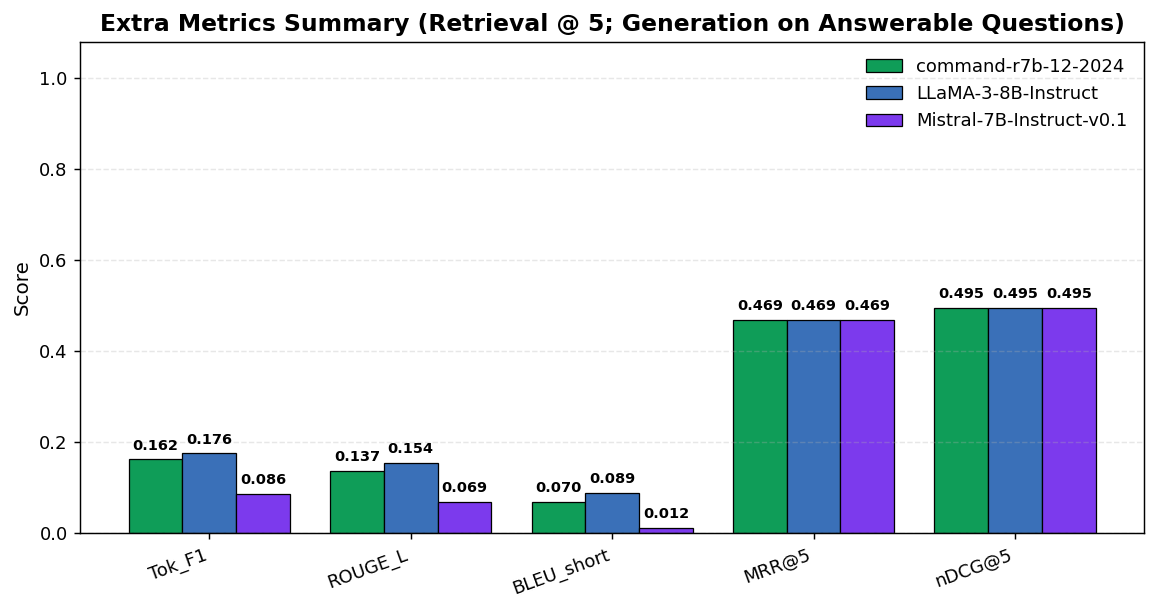

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_core_grouped_bar.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_core_grouped_bar.pdf


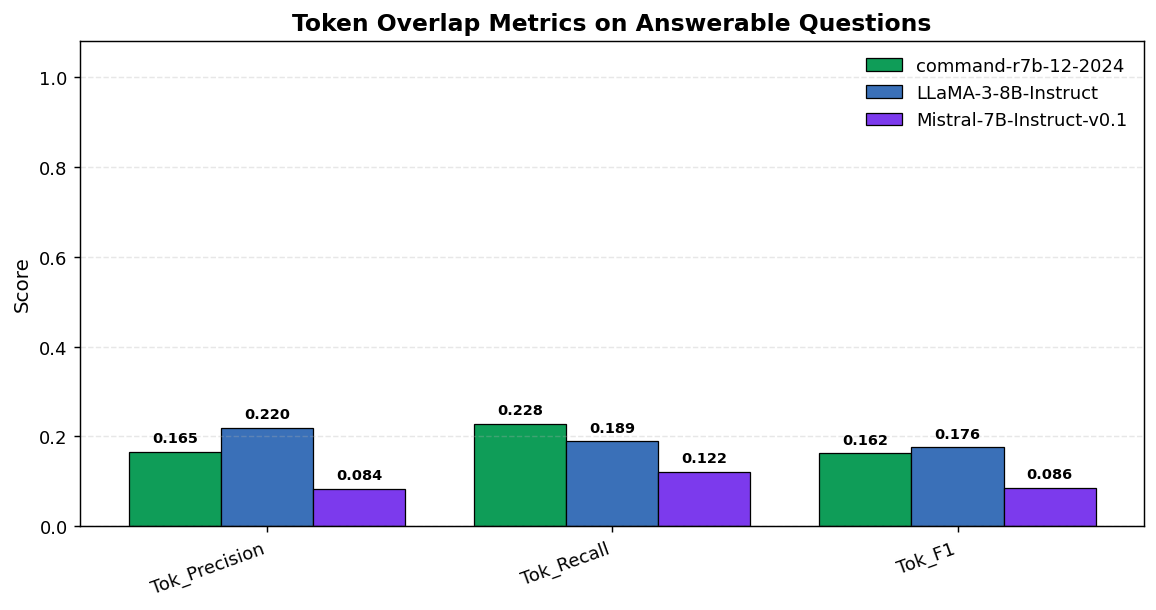

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_token_prf_grouped_bar.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_token_prf_grouped_bar.pdf


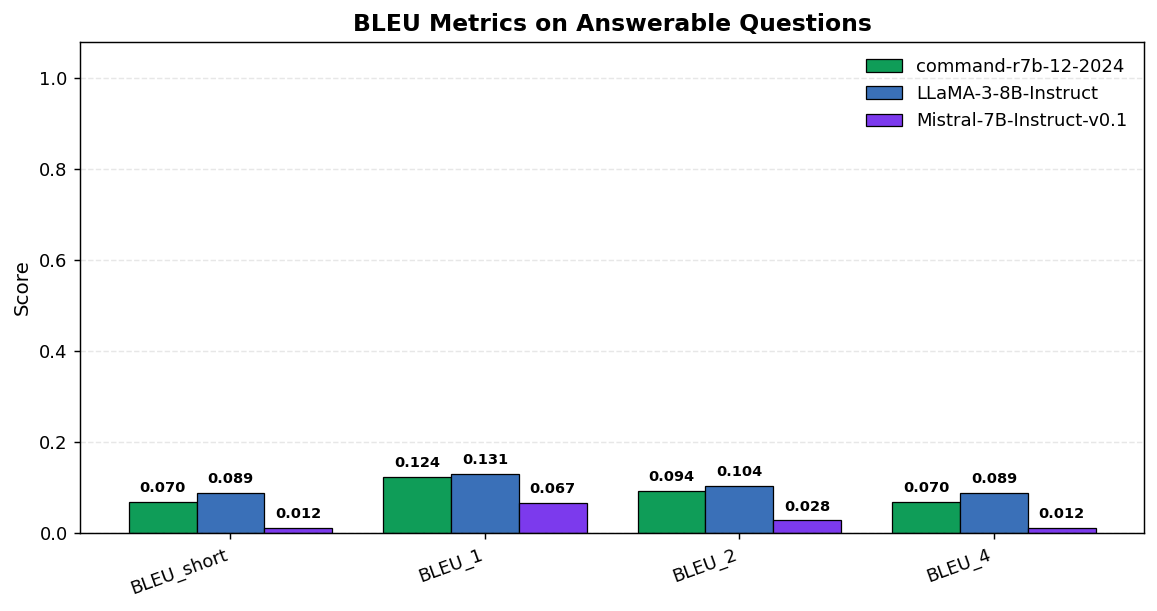

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_bleu_grouped_bar.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_bleu_grouped_bar.pdf


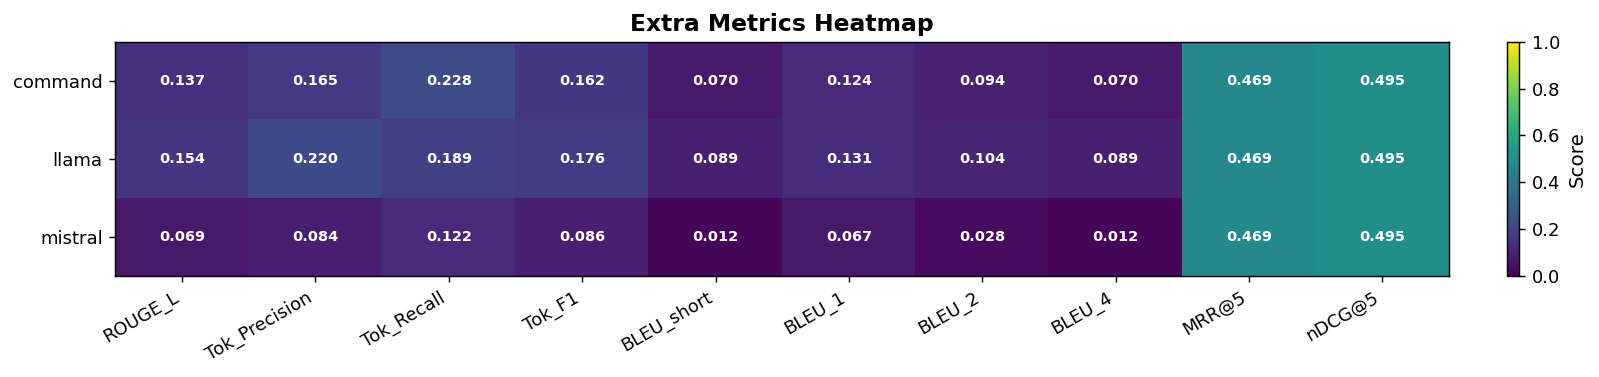

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_metrics_heatmap.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_metrics_heatmap.pdf


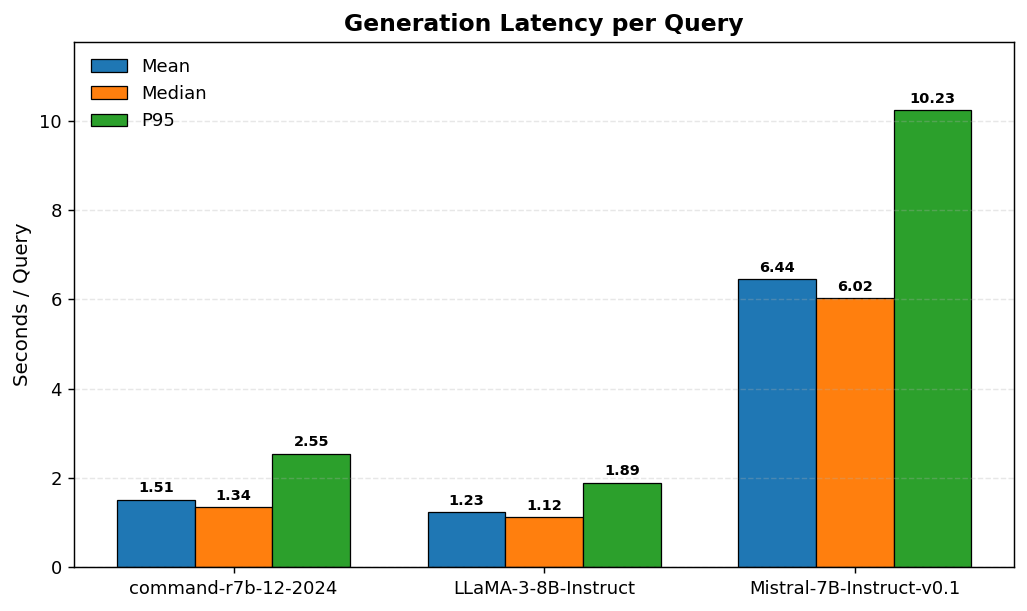

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_generation_latency.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_generation_latency.pdf

Done. Extra metrics and figures saved in: arabicaqa_rag_results\extra_metrics_llama_mistral_command


In [ ]:
# ============================================================
# FULL SCRIPT:
# Extra metrics for LLaMA + Mistral + Command
# Uses: comparison_llama_mistral_command_1000.csv
# - Retrieval metrics: MRR@K, nDCG@K
# - Generation metrics: ROUGE-L, BLEU, token Precision/Recall/F1
# - Saves per-question metrics
# - Saves model-level summary
# - Saves figures for 3+ models
# ============================================================

import os
import re
import ast
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import colormaps

# ============================================================
# CONFIG
# ============================================================
BASE_DIR = "arabicaqa_rag_results"

PRED_PATH = os.path.join(
    BASE_DIR,
    "predictions",
    "comparison_llama_mistral_command_1000.csv"
)

OUTPUT_DIR = os.path.join(BASE_DIR, "extra_metrics_llama_mistral_command")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

if not os.path.exists(PRED_PATH):
    raise FileNotFoundError(f"Prediction file not found: {PRED_PATH}")

TOPK = 5

CSV_SUMMARY_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_summary.csv")
JSON_SUMMARY_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_summary.json")
CSV_PER_QUESTION_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_per_question.csv")
JSON_PER_QUESTION_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_per_question.json")

MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "LLaMA-3-8B-Instruct",
    "mistral": "Mistral-7B-Instruct-v0.1",
}

# ============================================================
# LOAD
# ============================================================
df_results = pd.read_csv(PRED_PATH, encoding="utf-8-sig")

print("=" * 100)
print("EXTRA METRICS EVALUATION")
print("=" * 100)
print("Loaded:", PRED_PATH)
print("Shape:", df_results.shape)
print("Columns:", list(df_results.columns))

# ============================================================
# REQUIRED COLUMNS
# ============================================================
required_cols = [
    "question",
    "correct_answers",
    "is_impossible",
    "is_answerable",
    "document_id",
    "retrieved_doc_ids",
]

missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ============================================================
# DETECT MODELS
# ============================================================
prediction_prefix = "predicted_answer_"

model_keys = [
    c.replace(prediction_prefix, "")
    for c in df_results.columns
    if c.startswith(prediction_prefix)
]

if not model_keys:
    raise ValueError("No predicted_answer_* columns detected.")

print("\nDetected models:")
for m in model_keys:
    print(" -", m)

# ============================================================
# UTILITIES
# ============================================================
def safe_str(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x)

def safe_int(x, default=None):
    try:
        if x is None:
            return default
        if isinstance(x, float) and math.isnan(x):
            return default
        return int(float(x))
    except Exception:
        return default

def parse_bool(x):
    if pd.isna(x):
        return False

    if isinstance(x, bool):
        return x

    if isinstance(x, (int, float)):
        return bool(int(x))

    s = str(x).strip().lower()

    if s in ["true", "1", "yes", "y"]:
        return True

    if s in ["false", "0", "no", "n"]:
        return False

    return False

def parse_maybe_list(x):
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [str(v).strip() for v in parsed if str(v).strip()]
            except Exception:
                pass

        return [s]

    return [str(x).strip()] if str(x).strip() else []

def parse_retrieved_doc_ids(x):
    values = parse_maybe_list(x)
    out = []

    for v in values:
        iv = safe_int(v, default=None)
        if iv is not None:
            out.append(iv)

    return out

def first_ref(x):
    refs = parse_maybe_list(x)
    return refs[0] if refs else ""

def normalize_arabic_text(s):
    s = safe_str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize Arabic variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

def tokenize_arabic_simple(s):
    return normalize_arabic_text(s).split()

# ============================================================
# FIX BOOLEAN COLUMNS SAFELY
# ============================================================
df_results["is_impossible"] = df_results["is_impossible"].apply(parse_bool)
df_results["is_answerable"] = df_results["is_answerable"].apply(parse_bool)

print("\nBoolean check:")
print("is_impossible:")
print(df_results["is_impossible"].value_counts(dropna=False))
print("\nis_answerable:")
print(df_results["is_answerable"].value_counts(dropna=False))

# Safety consistency check
inconsistent = (df_results["is_answerable"] == df_results["is_impossible"]).sum()
if inconsistent > 0:
    print(f"\nWARNING: Found {inconsistent} rows where is_answerable == is_impossible.")
    print("Fixing is_answerable as the opposite of is_impossible.")
    df_results["is_answerable"] = ~df_results["is_impossible"]

# ============================================================
# RETRIEVAL METRICS
# ============================================================
def mrr_at_k(gold_doc_id, retrieved_doc_ids, k):
    if gold_doc_id is None or not isinstance(retrieved_doc_ids, list):
        return np.nan

    if len(retrieved_doc_ids) == 0:
        return np.nan

    for i, rid in enumerate(retrieved_doc_ids[:k]):
        if rid == gold_doc_id:
            return 1.0 / (i + 1)

    return 0.0

def ndcg_at_k_single_hit(gold_doc_id, retrieved_doc_ids, k):
    if gold_doc_id is None or not isinstance(retrieved_doc_ids, list):
        return np.nan

    if len(retrieved_doc_ids) == 0:
        return np.nan

    for i, rid in enumerate(retrieved_doc_ids[:k]):
        if rid == gold_doc_id:
            return 1.0 / np.log2(i + 2)

    return 0.0

df_results["gold_document_id_int"] = df_results["document_id"].apply(safe_int)
df_results["retrieved_doc_ids_parsed"] = df_results["retrieved_doc_ids"].apply(parse_retrieved_doc_ids)

print("\nRetrieved doc ids check:")
print(df_results["retrieved_doc_ids_parsed"].head().to_string(index=False))
print("Rows with empty retrieved_doc_ids:", (df_results["retrieved_doc_ids_parsed"].apply(len) == 0).sum())

df_results[f"MRR@{TOPK}"] = df_results.apply(
    lambda r: mrr_at_k(
        r["gold_document_id_int"],
        r["retrieved_doc_ids_parsed"],
        TOPK
    ),
    axis=1
)

df_results[f"nDCG@{TOPK}"] = df_results.apply(
    lambda r: ndcg_at_k_single_hit(
        r["gold_document_id_int"],
        r["retrieved_doc_ids_parsed"],
        TOPK
    ),
    axis=1
)

retrieval_mrr_mean = float(df_results[f"MRR@{TOPK}"].mean(skipna=True))
retrieval_ndcg_mean = float(df_results[f"nDCG@{TOPK}"].mean(skipna=True))

print(f"\n[Retrieval] MRR@{TOPK}: {retrieval_mrr_mean:.6f}")
print(f"[Retrieval] nDCG@{TOPK}: {retrieval_ndcg_mean:.6f}")

# ============================================================
# GENERATION METRICS
# ============================================================
def token_prf_single(pred, ref):
    pred_tokens = tokenize_arabic_simple(pred)
    ref_tokens = tokenize_arabic_simple(ref)

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0, 1.0, 1.0

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0, 0.0, 0.0

    pred_counts = Counter(pred_tokens)
    ref_counts = Counter(ref_tokens)

    overlap = sum((pred_counts & ref_counts).values())

    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return precision, recall, f1

def lcs_length(a, b):
    n, m = len(a), len(b)

    if n == 0 or m == 0:
        return 0

    dp = [0] * (m + 1)

    for i in range(1, n + 1):
        prev = 0
        for j in range(1, m + 1):
            temp = dp[j]
            if a[i - 1] == b[j - 1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = temp

    return dp[m]

def rouge_l_single(pred, ref):
    pred_tokens = tokenize_arabic_simple(pred)
    ref_tokens = tokenize_arabic_simple(ref)

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    lcs = lcs_length(pred_tokens, ref_tokens)

    precision = lcs / len(pred_tokens)
    recall = lcs / len(ref_tokens)

    if precision + recall == 0:
        return 0.0

    beta = precision / (recall + 1e-12)
    rouge_l = ((1 + beta**2) * precision * recall) / (recall + beta**2 * precision + 1e-12)

    return float(rouge_l)

def modified_precision(pred_tokens, ref_tokens, n):
    if len(pred_tokens) < n:
        return 0.0

    pred_ngrams = Counter(tuple(pred_tokens[i:i+n]) for i in range(len(pred_tokens) - n + 1))
    ref_ngrams = Counter(tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens) - n + 1))

    overlap = sum((pred_ngrams & ref_ngrams).values())
    total = sum(pred_ngrams.values())

    if total == 0:
        return 0.0

    return overlap / total

def bleu_score(pred, ref, max_n=4):
    pred_tokens = tokenize_arabic_simple(pred)
    ref_tokens = tokenize_arabic_simple(ref)

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    effective_n = min(max_n, len(pred_tokens), len(ref_tokens))

    if effective_n <= 0:
        return 0.0

    precisions = []

    for n in range(1, effective_n + 1):
        p = modified_precision(pred_tokens, ref_tokens, n)
        # smoothing
        if p == 0:
            p = 1e-9
        precisions.append(p)

    log_precision = sum(math.log(p) for p in precisions) / effective_n

    pred_len = len(pred_tokens)
    ref_len = len(ref_tokens)

    if pred_len > ref_len:
        bp = 1.0
    else:
        bp = math.exp(1 - ref_len / pred_len)

    return float(bp * math.exp(log_precision))

def bleu_single(pred, ref):
    bleu_short = bleu_score(pred, ref, max_n=4)
    bleu_1 = bleu_score(pred, ref, max_n=1)
    bleu_2 = bleu_score(pred, ref, max_n=2)
    bleu_4 = bleu_score(pred, ref, max_n=4)

    return bleu_short, bleu_1, bleu_2, bleu_4

# ============================================================
# COMPUTE PER-QUESTION METRICS
# ============================================================
per_question_rows = []

for _, row in df_results.iterrows():
    base = {
        "row_idx": row.get("row_idx", row.name),
        "question_id": row.get("question_id", ""),
        "document_id": row.get("document_id", ""),
        "question": row.get("question", ""),
        "is_impossible": bool(row.get("is_impossible", False)),
        "is_answerable": bool(row.get("is_answerable", False)),
        f"MRR@{TOPK}": row.get(f"MRR@{TOPK}", np.nan),
        f"nDCG@{TOPK}": row.get(f"nDCG@{TOPK}", np.nan),
    }

    ref = first_ref(row.get("correct_answers", ""))

    for model_key in model_keys:
        pred_col = f"predicted_answer_{model_key}"
        gen_latency_col = f"latency_sec_{model_key}"
        error_col = f"error_{model_key}"

        pred = row.get(pred_col, "")

        out = base.copy()
        out["model"] = model_key
        out["prediction"] = pred
        out["reference"] = ref

        out["generation_latency_sec"] = row.get(gen_latency_col, np.nan) if gen_latency_col in df_results.columns else np.nan
        out["error"] = row.get(error_col, "") if error_col in df_results.columns else ""

        if bool(row.get("is_answerable", False)):
            tok_p, tok_r, tok_f1 = token_prf_single(pred, ref)
            rouge_l = rouge_l_single(pred, ref)
            bleu_short, bleu_1, bleu_2, bleu_4 = bleu_single(pred, ref)
        else:
            tok_p, tok_r, tok_f1 = np.nan, np.nan, np.nan
            rouge_l = np.nan
            bleu_short, bleu_1, bleu_2, bleu_4 = np.nan, np.nan, np.nan, np.nan

        out["Tok_Precision"] = tok_p
        out["Tok_Recall"] = tok_r
        out["Tok_F1"] = tok_f1
        out["ROUGE_L"] = rouge_l
        out["BLEU_short"] = bleu_short
        out["BLEU_1"] = bleu_1
        out["BLEU_2"] = bleu_2
        out["BLEU_4"] = bleu_4

        per_question_rows.append(out)

df_extra_pq = pd.DataFrame(per_question_rows)

# ============================================================
# SUMMARY
# ============================================================
generation_metric_cols = [
    "ROUGE_L",
    "Tok_Precision",
    "Tok_Recall",
    "Tok_F1",
    "BLEU_short",
    "BLEU_1",
    "BLEU_2",
    "BLEU_4",
]

summary_rows = []

for model_key in model_keys:
    df_m = df_extra_pq[df_extra_pq["model"] == model_key].copy()
    df_m_ans = df_m[df_m["is_answerable"] == True].copy()

    row = {
        "model": model_key,
        "n_questions_all": int(len(df_m)),
        "n_questions_answerable": int(len(df_m_ans)),
        f"MRR@{TOPK}": float(df_m[f"MRR@{TOPK}"].mean(skipna=True)),
        f"nDCG@{TOPK}": float(df_m[f"nDCG@{TOPK}"].mean(skipna=True)),
        "generation_latency_mean_sec": float(df_m["generation_latency_sec"].mean(skipna=True)),
        "generation_latency_median_sec": float(df_m["generation_latency_sec"].median(skipna=True)),
        "generation_latency_p95_sec": float(df_m["generation_latency_sec"].quantile(0.95)),
    }

    for metric_name in generation_metric_cols:
        row[metric_name] = float(df_m_ans[metric_name].mean(skipna=True))

    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

# ============================================================
# SAVE
# ============================================================
df_extra_pq.to_csv(CSV_PER_QUESTION_PATH, index=False, encoding="utf-8-sig")
df_extra_pq.to_json(JSON_PER_QUESTION_PATH, orient="records", force_ascii=False, indent=2)

df_summary.to_csv(CSV_SUMMARY_PATH, index=False, encoding="utf-8-sig")
df_summary.to_json(JSON_SUMMARY_PATH, orient="records", force_ascii=False, indent=2)

print("\nSaved:")
print("Per-question CSV:", CSV_PER_QUESTION_PATH)
print("Per-question JSON:", JSON_PER_QUESTION_PATH)
print("Summary CSV:", CSV_SUMMARY_PATH)
print("Summary JSON:", JSON_SUMMARY_PATH)

print("\nExtra metrics summary:")
print(df_summary.round(4).to_string(index=False))

df_summary_plot = df_summary.copy()
df_summary_plot["model"] = df_summary_plot["model"].map(
    lambda x: MODEL_DISPLAY_NAMES.get(str(x), str(x))
)

# ============================================================
# PLOTTING
# ============================================================
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

MODEL_COLORS = {
    "command-r7b-12-2024": "#0F9D58",
    "llama-3-8b-instruct": "#3A70B8",
    "mistral-7b-instruct-v0.1": "#7C3AED",
}

DEFAULT_COLOR = "#777777"

def save_and_show(fig, name):
    png = os.path.join(FIG_DIR, f"{name}.png")
    pdf = os.path.join(FIG_DIR, f"{name}.pdf")

    fig.tight_layout()
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Saved:", png)
    print("Saved:", pdf)

def grouped_bar(df, metrics, title, ylabel, filename):
    models = df["model"].astype(str).tolist()
    x = np.arange(len(metrics))
    width = 0.8 / max(len(models), 1)

    fig, ax = plt.subplots(figsize=(max(9, len(metrics) * 1.25), 4.8))

    for i, model in enumerate(models):
        values = (
            df[df["model"].astype(str) == model][metrics]
            .iloc[0]
            .astype(float)
            .values
        )

        offset = (i - (len(models) - 1) / 2) * width

        bars = ax.bar(
            x + offset,
            values,
            width,
            label=model,
            color=MODEL_COLORS.get(model.lower(), DEFAULT_COLOR),
            edgecolor="black",
            linewidth=0.7
        )

        # Add value labels on top of bars
        for bar, value in zip(bars, values):
            if np.isnan(value):
                continue

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.08)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    save_and_show(fig, filename)

# ============================================================
# CORE METRICS FIGURE
# ============================================================
core_metrics = [
    "Tok_F1",
    "ROUGE_L",
    "BLEU_short",
    f"MRR@{TOPK}",
    f"nDCG@{TOPK}",
]
core_metrics = [m for m in core_metrics if m in df_summary.columns]



grouped_bar(
    df_summary_plot,
    core_metrics,
    f"Extra Metrics Summary (Retrieval @ {TOPK}; Generation on Answerable Questions)",
    "Score",
    "extra_core_grouped_bar"
)

# ============================================================
# TOKEN PRF FIGURE
# ============================================================
prf_metrics = ["Tok_Precision", "Tok_Recall", "Tok_F1"]
prf_metrics = [m for m in prf_metrics if m in df_summary.columns]

grouped_bar(
    df_summary_plot,
    prf_metrics,
    "Token Overlap Metrics on Answerable Questions",
    "Score",
    "extra_token_prf_grouped_bar"
)

# ============================================================
# BLEU FIGURE
# ============================================================
bleu_metrics = ["BLEU_short", "BLEU_1", "BLEU_2", "BLEU_4"]
bleu_metrics = [m for m in bleu_metrics if m in df_summary.columns]

grouped_bar(
    df_summary_plot,
    bleu_metrics,
    "BLEU Metrics on Answerable Questions",
    "Score",
    "extra_bleu_grouped_bar"
)

# ============================================================
# HEATMAP
# ============================================================
heat_metrics = [
    "ROUGE_L",
    "Tok_Precision",
    "Tok_Recall",
    "Tok_F1",
    "BLEU_short",
    "BLEU_1",
    "BLEU_2",
    "BLEU_4",
    f"MRR@{TOPK}",
    f"nDCG@{TOPK}",
]
heat_metrics = [m for m in heat_metrics if m in df_summary.columns]

if heat_metrics:
    mat = df_summary.set_index("model")[heat_metrics].astype(float)

    cmap = colormaps["viridis"].copy()
    cmap.set_bad(color="lightgray")

    masked_values = np.ma.masked_invalid(mat.values)

    fig, ax = plt.subplots(figsize=(12.5, max(3.0, 0.65 * len(mat))))

    im = ax.imshow(masked_values, aspect="auto", vmin=0, vmax=1, cmap=cmap)

    ax.set_title("Extra Metrics Heatmap")
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_yticklabels(mat.index.tolist())

    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_xticklabels(mat.columns.tolist(), rotation=30, ha="right")

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]

            if np.isnan(val):
                label = "NA"
                text_color = "black"
            else:
                label = f"{val:.3f}"
                rgba = im.cmap(im.norm(val))
                r, g, b, _ = rgba
                luminance = 0.299 * r + 0.587 * g + 0.114 * b
                text_color = "black" if luminance > 0.55 else "white"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
                fontweight="bold"
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Score")

    save_and_show(fig, "extra_metrics_heatmap")

# ============================================================
# LATENCY FIGURE
# ============================================================
latency_metrics = [
    "generation_latency_mean_sec",
    "generation_latency_median_sec",
    "generation_latency_p95_sec",
]
latency_metrics = [m for m in latency_metrics if m in df_summary.columns]

if latency_metrics:
    models = df_summary_plot["model"].unique()
    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 4.8))

    bars_mean = ax.bar(
        x - width,
        df_summary_plot["generation_latency_mean_sec"],
        width,
        label="Mean",
        edgecolor="black",
        linewidth=0.7
    )

    bars_median = ax.bar(
        x,
        df_summary_plot["generation_latency_median_sec"],
        width,
        label="Median",
        edgecolor="black",
        linewidth=0.7
    )

    bars_p95 = ax.bar(
        x + width,
        df_summary_plot["generation_latency_p95_sec"],
        width,
        label="P95",
        edgecolor="black",
        linewidth=0.7
    )

    # Add value labels on top of latency bars
    for bars in [bars_mean, bars_median, bars_p95]:
        for bar in bars:
            value = bar.get_height()

            if np.isnan(value):
                continue

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + (0.01 * df_summary_plot["generation_latency_p95_sec"].max()),
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold"
            )

    ax.set_title("Generation Latency per Query")
    ax.set_ylabel("Seconds / Query")
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    # Add extra space above bars for labels
    ymax = df_summary_plot["generation_latency_p95_sec"].max()
    ax.set_ylim(0, ymax * 1.15)

    save_and_show(fig, "extra_generation_latency")

print("\nDone. Extra metrics and figures saved in:", OUTPUT_DIR)